# TASK 2 — KHÁM PHÁ MÓN ĂN MỚI (Content-Based Image Retrieval + Metric Learning)
**Dự án:** Hệ thống Khám phá & Gợi ý Ẩm thực — Môn Học Sâu  
**Phương pháp:** Metric Learning (Triplet Margin Loss) với cơ chế Hard-Negative Mining  
**Mô hình đánh giá (Backbones):**
1. **ResNet-50** (Baseline - Kế thừa từ `encoder.py` của Task 1)
2. **ViT-B/16** (Vision Transformer - Đề xuất cải tiến)

Notebook này thực hiện toàn bộ Pipeline cho Hệ thống Gợi ý (CBIR):
- **Xây dựng Kiến trúc:** Tích hợp Projection Head (512-dim) và L2-Normalization cho 2 mô hình (ResNet & ViT).
- **Huấn luyện Song song (Automation):** Cơ chế Skip-Training tự động bỏ qua nếu đã có sẵn Checkpoints.
- **Xây dựng Feature Bank:** Trích xuất vector đặc trưng (Embeddings) cho toàn bộ dataset.
- **Đánh giá Định lượng (Quantitative Evaluation):** So sánh hiệu suất truy xuất (Recall@5, Recall@10) giữa kiến trúc CNN (ResNet) và Transformer (ViT).
- **Trực quan hóa Nâng cao (Advanced Visualizations):**
  - Interactive Demo: Truy vấn "Novel Dish Discovery" để gợi ý top-K món ăn.
  - Biểu đồ Learning Curve (Train/Val Loss).
  - Không gian Vector t-SNE Clustering (Giảm chiều 512D -> 2D).
  - Bản đồ Chú ý (ViT Attention Map - Explainable AI).

---
**Cấu trúc JSON Dataset** (đồng nhất với `dataset.py` — Task 1):
```json
[
  {
    "image_path": "data/images/am_thuc/vịt_quay/000010.jpg",
    "qa_pairs": [{"question": "...", "answer": "..."}]
  }
]
```

In [1]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")

!pip install -q torch torchvision tqdm matplotlib Pillow

True
NVIDIA A100-SXM4-80GB


In [7]:
# ── Standard library ──────────────────────────────────────────────────────────
import os
import json
import random
import math
from pathlib import Path
from collections import defaultdict
from typing import Dict, List, Optional, Tuple

# ── Scientific & Vision ───────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from tqdm import tqdm

# ── PyTorch ───────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

# ── Device (Multi-device: CUDA / MPS / CPU) ───────────────────────────────────
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

print(f"Device       : {DEVICE}")

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if DEVICE.type == 'cuda':
    torch.cuda.manual_seed_all(SEED)

from google.colab import drive
drive.mount('/content/drive')

# ── CHỈNH SỬA PHẦN NÀY THEO CẤU TRÚC DRIVE CỦA BẠN ─────────────────────────
DATA_ROOT  = "/content/drive/MyDrive/VQA_Dataset/Vietnamese_Cuisine_v1.0"
IMG_DIR    = os.path.join(DATA_ROOT, "images")
TRAIN_JSON = os.path.join(DATA_ROOT, "splits", "train.json")
VAL_JSON   = os.path.join(DATA_ROOT, "splits", "val.json")
TEST_JSON  = os.path.join(DATA_ROOT, "splits", "test.json")

# ── Output paths ─────────────────────────────────────────────────────────────
CKPT_DIR         = os.path.join(DATA_ROOT, "cbir_checkpoints")
BEST_CKPT_PATH_RESNET = os.path.join(CKPT_DIR, "best_cbir_resnet.pth")
BEST_CKPT_PATH_VIT    = os.path.join(CKPT_DIR, "best_cbir_vit.pth")
FEATURE_BANK_PATH_RESNET = os.path.join(CKPT_DIR, "feature_bank_resnet.pt")
FEATURE_BANK_PATH_VIT    = os.path.join(CKPT_DIR, "feature_bank_vit.pt")
os.makedirs(CKPT_DIR, exist_ok=True)

# ── Hyperparameters ──────────────────────────────────────────────────────────
EMBED_DIM        = 512
BATCH_SIZE       = 32
EPOCHS           = 30
LR               = 3e-4
WEIGHT_DECAY     = 1e-4
TRIPLET_MARGIN   = 0.5
PATIENCE         = 5
TOP_K            = 5
NUM_WORKERS      = 2

Device       : cuda
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# TRANSFORM — kế thừa HOÀN TOÀN từ dataset.py (Task 1)
# ══════════════════════════════════════════════════════════════════════════════
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

TRAIN_TRANSFORM = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

VAL_TRANSFORM = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

def resolve_image_path(image_path: str, img_root: str) -> str:
    image_path = image_path.replace('\\', '/')
    marker = 'am_thuc/'
    idx = image_path.find(marker)
    if idx != -1:
        relative = image_path[idx:]
        parts = relative.split('/')
        if len(parts) >= 2:
            parts[1] = parts[1].replace(' ', '_')
        return os.path.join(img_root, '/'.join(parts))
    return os.path.join(img_root, os.path.basename(image_path))

def extract_label_from_path(image_path: str) -> str:
    parts = image_path.replace('\\', '/').split('/')
    try:
        idx = next(i for i, p in enumerate(parts) if p == 'am_thuc')
        return parts[idx + 1].replace(' ', '_')
    except (StopIteration, IndexError):
        return os.path.basename(os.path.dirname(image_path))

class FoodCBIRDataset(Dataset):
    def __init__(self, json_path: str, img_root: str, transform: transforms.Compose, label2idx: Optional[Dict[str, int]] = None) -> None:
        self.img_root  = img_root
        self.transform = transform
        with open(json_path, 'r', encoding='utf-8') as f:
            raw_data = json.load(f)

        self.samples: List[Tuple[str, str]] = []
        for item in raw_data:
            if 'image_path' in item:
                path  = resolve_image_path(item['image_path'], img_root)
                label = extract_label_from_path(item['image_path'])
            else:
                category = item.get('category', 'am_thuc')
                keyword  = item.get('keyword', '').replace(' ', '_')
                image_id = item['image_id']
                path  = os.path.join(img_root, category, keyword, f"{image_id}.jpg")
                label = keyword
            self.samples.append((path, label))

        if label2idx is None:
            unique_labels = sorted(set(s[1] for s in self.samples))
            self.label2idx: Dict[str, int] = {l: i for i, l in enumerate(unique_labels)}
        else:
            self.label2idx = label2idx
        self.idx2label: Dict[int, str] = {v: k for k, v in self.label2idx.items()}
        self.num_classes = len(self.label2idx)

    def __len__(self) -> int: return len(self.samples)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, int, str]:
        path, label_str = self.samples[idx]
        label_int = self.label2idx.get(label_str, 0)
        try:
            img = Image.open(path).convert('RGB')
            img = self.transform(img)
        except Exception:
            img = torch.zeros(3, 224, 224)
        return img, label_int, path

class TripletFoodDataset(Dataset):
    def __init__(self, base_dataset: FoodCBIRDataset) -> None:
        self.base = base_dataset
        self.class_to_indices: Dict[int, List[int]] = defaultdict(list)
        for i, (_, label_str) in enumerate(base_dataset.samples):
            label_int = base_dataset.label2idx.get(label_str, 0)
            self.class_to_indices[label_int].append(i)

        self.valid_classes: List[int] = [c for c, idxs in self.class_to_indices.items() if len(idxs) >= 2]
        self.anchor_pool: List[int] = [i for c in self.valid_classes for i in self.class_to_indices[c]]

    def __len__(self) -> int: return len(self.anchor_pool)

    def _load(self, idx: int) -> torch.Tensor:
        img, _, _ = self.base[idx]
        return img

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        anchor_idx   = self.anchor_pool[idx]
        _, anchor_label_str = self.base.samples[anchor_idx]
        anchor_class = self.base.label2idx.get(anchor_label_str, 0)

        pos_pool = [i for i in self.class_to_indices[anchor_class] if i != anchor_idx]
        pos_idx  = random.choice(pos_pool)

        neg_class = random.choice([c for c in self.valid_classes if c != anchor_class])
        neg_idx   = random.choice(self.class_to_indices[neg_class])

        return self._load(anchor_idx), self._load(pos_idx), self._load(neg_idx)

# Nạp dữ liệu
train_base    = FoodCBIRDataset(TRAIN_JSON, IMG_DIR, TRAIN_TRANSFORM)
val_base      = FoodCBIRDataset(VAL_JSON,   IMG_DIR, VAL_TRANSFORM, label2idx=train_base.label2idx)
test_base     = FoodCBIRDataset(TEST_JSON,  IMG_DIR, VAL_TRANSFORM, label2idx=train_base.label2idx)

train_triplet = TripletFoodDataset(train_base)
val_triplet   = TripletFoodDataset(val_base)

train_loader = DataLoader(train_triplet, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=(DEVICE.type == 'cuda'))
val_loader   = DataLoader(val_triplet,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=(DEVICE.type == 'cuda'))

from torch.utils.data import ConcatDataset
full_base = ConcatDataset([train_base, val_base, test_base])
bank_loader = DataLoader(full_base, batch_size=64, shuffle=False, num_workers=NUM_WORKERS)

In [9]:
class FoodEmbeddingNet(nn.Module):
    def __init__(self, embed_dim: int = 512, fine_tune_last_block: bool = True) -> None:
        super().__init__()
        self.embed_dim = embed_dim

        resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        modules = list(resnet.children())[:-1]
        self.backbone = nn.Sequential(*modules)

        for param in self.backbone.parameters():
            param.requires_grad = False

        if fine_tune_last_block:
            for param in self.backbone[-2].parameters():
                param.requires_grad = True

        self.projection_head = nn.Sequential(
            nn.Linear(2048, 1024, bias=False),
            nn.BatchNorm1d(1024),
            nn.ReLU(inplace=True),
            nn.Linear(1024, embed_dim, bias=False),
            nn.BatchNorm1d(embed_dim),
        )
        self._init_projection_head()

    def _init_projection_head(self) -> None:
        for m in self.projection_head.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1.0)
                nn.init.constant_(m.bias,   0.0)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        feat = self.backbone(x)
        feat = torch.flatten(feat, 1)
        emb  = self.projection_head(feat)
        emb  = F.normalize(emb, p=2, dim=1)      # Chuẩn hóa L2
        return emb

class FoodEmbeddingNetViT(nn.Module):
    def __init__(self, embed_dim: int = 512, fine_tune_last_block: bool = True) -> None:
        super().__init__()
        self.embed_dim = embed_dim

        # Load ViT pre-trained
        self.backbone = models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT)

        # Freeze backbone
        for param in self.backbone.parameters():
            param.requires_grad = False

        # Optionally fine-tune last encoder block
        if fine_tune_last_block:
            for param in self.backbone.encoder.layers[-1].parameters():
                param.requires_grad = True

        in_features = self.backbone.heads.head.in_features
        self.backbone.heads = nn.Sequential(
            nn.Linear(in_features, 1024, bias=False),
            nn.BatchNorm1d(1024),
            nn.ReLU(inplace=True),
            nn.Linear(1024, embed_dim, bias=False),
            nn.BatchNorm1d(embed_dim),
        )
        self._init_projection_head()

    def _init_projection_head(self) -> None:
        for m in self.backbone.heads.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1.0)
                nn.init.constant_(m.bias,   0.0)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        emb = self.backbone(x)
        emb = F.normalize(emb, p=2, dim=1)      # L2 Normalize
        return emb

model_resnet = FoodEmbeddingNet(embed_dim=EMBED_DIM, fine_tune_last_block=True).to(DEVICE)
model_vit = FoodEmbeddingNetViT(embed_dim=EMBED_DIM, fine_tune_last_block=True).to(DEVICE)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 230MB/s]


Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 198MB/s]


In [10]:
criterion = nn.TripletMarginLoss(margin=TRIPLET_MARGIN, p=2, reduction='mean')

class EarlyStopping:
    def __init__(self, patience: int = 5, min_delta: float = 1e-4) -> None:
        self.patience, self.min_delta, self.best_loss, self.counter, self.should_stop = patience, min_delta, float('inf'), 0, False

    def step(self, val_loss: float) -> bool:
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss, self.counter = val_loss, 0
        else:
            self.counter += 1
            if self.counter >= self.patience: self.should_stop = True
        return self.should_stop

def train_one_epoch(model, loader, criterion, optimizer, device, max_grad_norm=1.0) -> float:
    model.train()
    total_loss = 0.0
    for anchor, positive, negative in tqdm(loader, desc='  Train', leave=False):
        anchor, positive, negative = anchor.to(device), positive.to(device), negative.to(device)
        optimizer.zero_grad()
        loss = criterion(model(anchor), model(positive), model(negative))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=max_grad_norm)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / max(len(loader), 1)

@torch.no_grad()
def validate(model, loader, criterion, device) -> float:
    model.eval()
    total_loss = 0.0
    for anchor, positive, negative in tqdm(loader, desc='  Val  ', leave=False):
        anchor, positive, negative = anchor.to(device), positive.to(device), negative.to(device)
        total_loss += criterion(model(anchor), model(positive), model(negative)).item()
    return total_loss / max(len(loader), 1)

def run_training_pipeline(model, ckpt_path, feature_bank_path, model_name="Model"):
    print(f"\n{'='*50}\n🚀 BẮT ĐẦU HUẤN LUYỆN: {model_name}\n{'='*50}")

    # 1. Kiểm tra Checkpoint
    if os.path.exists(ckpt_path) and os.path.exists(feature_bank_path):
        print(f"✅ Đã tìm thấy checkpoint tại: {ckpt_path}")
        print("⏭️ Bỏ qua quá trình huấn luyện, tải model từ checkpoint...")
        return

    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
    early_stop = EarlyStopping(patience=PATIENCE)
    best_val_loss = float('inf')

    for epoch in range(1, EPOCHS + 1):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
        val_loss   = validate(model, val_loader, criterion, DEVICE)
        scheduler.step()

        is_best = val_loss < best_val_loss
        if is_best:
            best_val_loss = val_loss
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state': optimizer.state_dict(),
                'val_loss': best_val_loss,
                'embed_dim': EMBED_DIM,
                'label2idx': train_base.label2idx
            }, ckpt_path)

        print(f"Epoch {epoch:3d}/{EPOCHS} | Train: {train_loss:.4f} | Val: {val_loss:.4f}" + (" ⭐ Best" if is_best else ""))
        if early_stop.step(val_loss):
            print("⏹️ Early stopping triggered!")
            break

# Gọi hàm huấn luyện cho cả 2 mô hình
run_training_pipeline(model_resnet, BEST_CKPT_PATH_RESNET, FEATURE_BANK_PATH_RESNET, "ResNet-50")
run_training_pipeline(model_vit, BEST_CKPT_PATH_VIT, FEATURE_BANK_PATH_VIT, "ViT-B/16")


🚀 BẮT ĐẦU HUẤN LUYỆN: ResNet-50


  Train:   0%|          | 0/32 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
  Train:  12%|█▎        | 4/32 [01:57<11:00, 23.60s/it]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch   1/30 | Train: 0.3404 | Val: 0.2377 ⭐ Best


  Train:   0%|          | 0/32 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
  Train:  12%|█▎        | 4/32 [00:05<00:34,  1.24s/it]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch   2/30 | Train: 0.1827 | Val: 0.1485 ⭐ Best


...

Epoch  12/30 | Train: 0.0275 | Val: 0.0877


  Train:  12%|█▎        | 4/32 [00:06<00:37,  1.35s/it]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
  Train:  19%|█▉        | 6/32 [00:09<00:34,  1.32s/it]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch  13/30 | Train: 0.0289 | Val: 0.0975


  Train:   0%|          | 0/32 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
  Train:   6%|▋         | 2/32 [00:03<00:48,  1.61s/it]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
                                                      

Epoch  14/30 | Train: 0.0253 | Val: 0.0827
⏹️ Early stopping triggered!


In [11]:
@torch.no_grad()
def build_feature_bank(model, dataloader, device, save_path):
    model.eval()
    all_feats, all_labels, all_paths = [], [], []
    for imgs, labels, paths in tqdm(dataloader, desc=f'Building Feature Bank'):
        feats = model(imgs.to(device, non_blocking=True))
        all_feats.append(feats.cpu())
        all_labels.append(labels.cpu())
        all_paths.extend(list(paths))

    feature_bank = torch.cat(all_feats, dim=0)
    label_bank   = torch.cat(all_labels, dim=0)
    torch.save({'feature_bank': feature_bank, 'label_bank': label_bank, 'path_bank': all_paths, 'embed_dim': feature_bank.shape[1]}, save_path)
    return feature_bank, label_bank, all_paths

def load_and_build(model, ckpt_path, bank_path):
    ckpt = torch.load(ckpt_path, map_location=DEVICE)
    model.load_state_dict(ckpt['model_state_dict'])
    label2idx_ckpt = ckpt['label2idx']
    idx2label_ckpt = {v: k for k, v in label2idx_ckpt.items()}

    if os.path.exists(bank_path):
        print(f"Nạp Feature Bank từ: {bank_path}")
        data = torch.load(bank_path, map_location='cpu')
        return data['feature_bank'], data['label_bank'], data['path_bank'], idx2label_ckpt
    else:
        feature_bank, label_bank, path_bank = build_feature_bank(model, bank_loader, DEVICE, bank_path)
        return feature_bank, label_bank, path_bank, idx2label_ckpt

print("\n--- Nạp mô hình và Feature Bank cho ResNet-50 ---")
feat_bank_res, lbl_bank_res, path_bank_res, idx2lbl_res = load_and_build(model_resnet, BEST_CKPT_PATH_RESNET, FEATURE_BANK_PATH_RESNET)

print("\n--- Nạp mô hình và Feature Bank cho ViT-B/16 ---")
feat_bank_vit, lbl_bank_vit, path_bank_vit, idx2lbl_vit = load_and_build(model_vit, BEST_CKPT_PATH_VIT, FEATURE_BANK_PATH_VIT)

@torch.no_grad()
def recommend_novel_dishes(query_emb, query_label, feature_bank, label_bank, top_k=5):
    query_emb = query_emb.view(1, -1).float()
    bank = feature_bank.float()
    sim = torch.mm(query_emb, bank.T).squeeze(0)
    same_label_mask = (label_bank == query_label)
    sim = sim.masked_fill(same_label_mask, float('-inf'))
    top_scores, top_indices = torch.topk(sim, k=min(top_k, (sim != float('-inf')).sum().item()))
    return top_indices, top_scores

@torch.no_grad()
def embed_single_image(model, image_path, transform, device):
    model.eval()
    try: img = Image.open(image_path).convert('RGB')
    except Exception: return torch.zeros(model.embed_dim)
    return model(transform(img).unsqueeze(0).to(device)).squeeze(0).cpu()


--- Nạp mô hình và Feature Bank cho ResNet-50 ---


Building Feature Bank:   0%|          | 0/20 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Building Feature Bank:  15%|█▌        | 3/20 [00:03<00:21,  1.28s/it]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Building Feature Bank: 100%|██████████| 20/20 [01:07<00:00,  3.35s/it]



--- Nạp mô hình và Feature Bank cho ViT-B/16 ---


Building Feature Bank:   0%|          | 0/20 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Building Feature Bank:  20%|██        | 4/20 [00:04<00:13,  1.22it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Building Feature Bank: 100%|██████████| 20/20 [00:19<00:00,  1.01it/s]


In [12]:
def visualize_results(query_img_path, query_label_name, top_k_paths, top_k_scores, top_k_label_names, title=None, save_path=None):
    n_cols = 1 + len(top_k_paths)
    fig, axes = plt.subplots(1, n_cols, figsize=(3.5 * n_cols, 4.5), dpi=130)
    if n_cols == 1: axes = [axes]

    def safe_load_img(path):
        try: return np.array(Image.open(path).convert('RGB').resize((224, 224)))
        except Exception: return None

    # Vẽ Query
    ax = axes[0]
    img_arr = safe_load_img(query_img_path)
    if img_arr is not None: ax.imshow(img_arr)
    ax.set_title(f"📷 QUERY\n{query_label_name.replace('_', ' ')}", fontsize=10, fontweight='bold', color='#8B6914', pad=6)
    for spine in ax.spines.values():
        spine.set_edgecolor('#FFD700')
        spine.set_linewidth(3)
    ax.set_xticks([]); ax.set_yticks([])

    # Vẽ Top-K
    scores_list = top_k_scores.tolist() if isinstance(top_k_scores, torch.Tensor) else top_k_scores
    for rank, (path, score, lbl) in enumerate(zip(top_k_paths, scores_list, top_k_label_names), start=1):
        ax = axes[rank]
        img_arr = safe_load_img(path)
        if img_arr is not None: ax.imshow(img_arr)
        ax.set_title(f"Top-{rank}  Sim: {score*100:.1f}%\n{lbl.replace('_', ' ')}", fontsize=9.5, fontweight='bold', color='#145214', pad=6)
        for spine in ax.spines.values():
            spine.set_edgecolor('#2ca02c')
            spine.set_linewidth(2.5)
        ax.set_xticks([]); ax.set_yticks([])

    if title is None: title = f'🍜 Novel Dish Discovery — Top-{len(top_k_paths)} Gợi ý Khác Loại'
    fig.suptitle(title, fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


--- ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP TEST ---


Evaluating ResNet-50 (Recall@5):  75%|███████▌  | 3/4 [00:01<00:00,  1.85it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Evaluating ResNet-50 (Recall@5): 100%|██████████| 4/4 [00:02<00:00,  1.80it/s]


ResNet-50 Recall@5: 73.81%


Evaluating ViT-B/16 (Recall@5):  75%|███████▌  | 3/4 [00:01<00:00,  1.81it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Evaluating ViT-B/16 (Recall@5): 100%|██████████| 4/4 [00:02<00:00,  1.72it/s]


ViT-B/16 Recall@5: 76.98%


Evaluating ResNet-50 (Recall@10):  75%|███████▌  | 3/4 [00:01<00:00,  1.84it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Evaluating ResNet-50 (Recall@10): 100%|██████████| 4/4 [00:02<00:00,  1.76it/s]


ResNet-50 Recall@10: 76.98%


Evaluating ViT-B/16 (Recall@10):  75%|███████▌  | 3/4 [00:01<00:00,  1.82it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Evaluating ViT-B/16 (Recall@10): 100%|██████████| 4/4 [00:02<00:00,  1.72it/s]

ViT-B/16 Recall@10: 79.37%


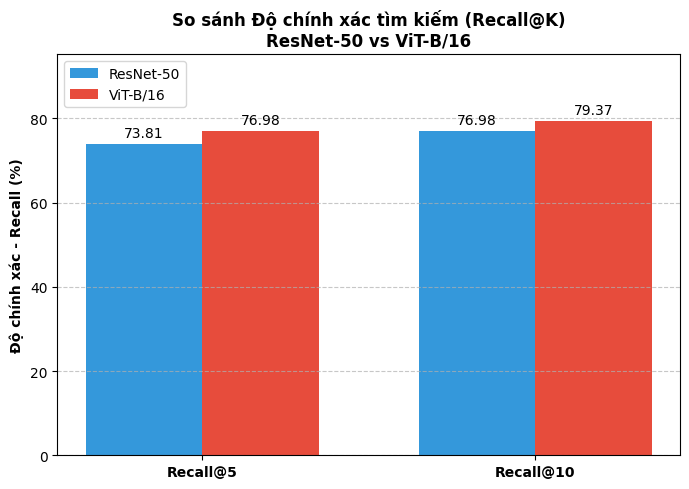

In [22]:
def calculate_recall_at_k(model, feature_bank, label_bank, dataloader, device, k=5, model_name="Model"):
    model.eval()
    correct = 0
    total = 0

    feature_bank = feature_bank.to(device).float()
    label_bank = label_bank.to(device)

    with torch.no_grad():
        for imgs, labels, _ in tqdm(dataloader, desc=f'Evaluating {model_name} (Recall@{k})'):
            imgs = imgs.to(device)
            labels = labels.to(device)

            query_embs = model(imgs).float()

            # B x N similarity matrix
            sims = torch.mm(query_embs, feature_bank.T)

            # TRÁNH LỖI SELF-RETRIEVAL: Mask chính bức ảnh đó (sim ≈ 1.0)\n
            sims.masked_fill_(sims > 0.99, float('-inf'))
            # Lấy top K indices
            topk_scores, topk_indices = torch.topk(sims, k=k, dim=1)

            # Lấy labels tương ứng với top K indices
            topk_labels = torch.gather(label_bank.unsqueeze(0).expand(imgs.size(0), -1), 1, topk_indices)

            # Kiểm tra xem label đúng có nằm trong top K không
            correct_mask = (topk_labels == labels.unsqueeze(1))
            correct += correct_mask.any(dim=1).sum().item()
            total += imgs.size(0)

    recall = (correct / total) * 100
    print(f"{model_name} Recall@{k}: {recall:.2f}%")
    return recall

print("\n--- ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP TEST ---")
# Giải phóng RAM nếu cần thiết bằng cách chuyển bank về GPU trong hàm
test_loader_eval = DataLoader(test_base, batch_size=32, shuffle=False, num_workers=NUM_WORKERS)
r5_res = calculate_recall_at_k(model_resnet, feat_bank_res, lbl_bank_res, test_loader_eval, DEVICE, k=5, model_name="ResNet-50")
r5_vit = calculate_recall_at_k(model_vit, feat_bank_vit, lbl_bank_vit, test_loader_eval, DEVICE, k=5, model_name="ViT-B/16")
r10_res = calculate_recall_at_k(model_resnet, feat_bank_res, lbl_bank_res, test_loader_eval, DEVICE, k=10, model_name="ResNet-50")
r10_vit = calculate_recall_at_k(model_vit, feat_bank_vit, lbl_bank_vit, test_loader_eval, DEVICE, k=10, model_name="ViT-B/16")

# --- VẼ BIỂU ĐỒ SO SÁNH METRICS ---
import matplotlib.pyplot as plt
import numpy as np

def plot_metrics_comparison(r5_res, r5_vit, r10_res, r10_vit):
    labels = ['Recall@5', 'Recall@10']
    resnet_scores = [r5_res, r10_res]
    vit_scores = [r5_vit, r10_vit]

    x = np.arange(len(labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(7, 5), dpi=100)
    rects1 = ax.bar(x - width/2, resnet_scores, width, label='ResNet-50', color='#3498db')
    rects2 = ax.bar(x + width/2, vit_scores, width, label='ViT-B/16', color='#e74c3c')

    ax.set_ylabel('Độ chính xác - Recall (%)', fontweight='bold')
    ax.set_title('So sánh Độ chính xác tìm kiếm (Recall@K)\nResNet-50 vs ViT-B/16', fontweight='bold', fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontweight='bold')
    ax.legend()
    ax.set_ylim(0, max(max(resnet_scores), max(vit_scores)) * 1.2)

    ax.bar_label(rects1, fmt='%.2f', padding=3)
    ax.bar_label(rects2, fmt='%.2f', padding=3)

    plt.grid(axis='y', linestyle='--', alpha=0.7)
    fig.tight_layout()
    plt.show()

plot_metrics_comparison(r5_res, r5_vit, r10_res, r10_vit)

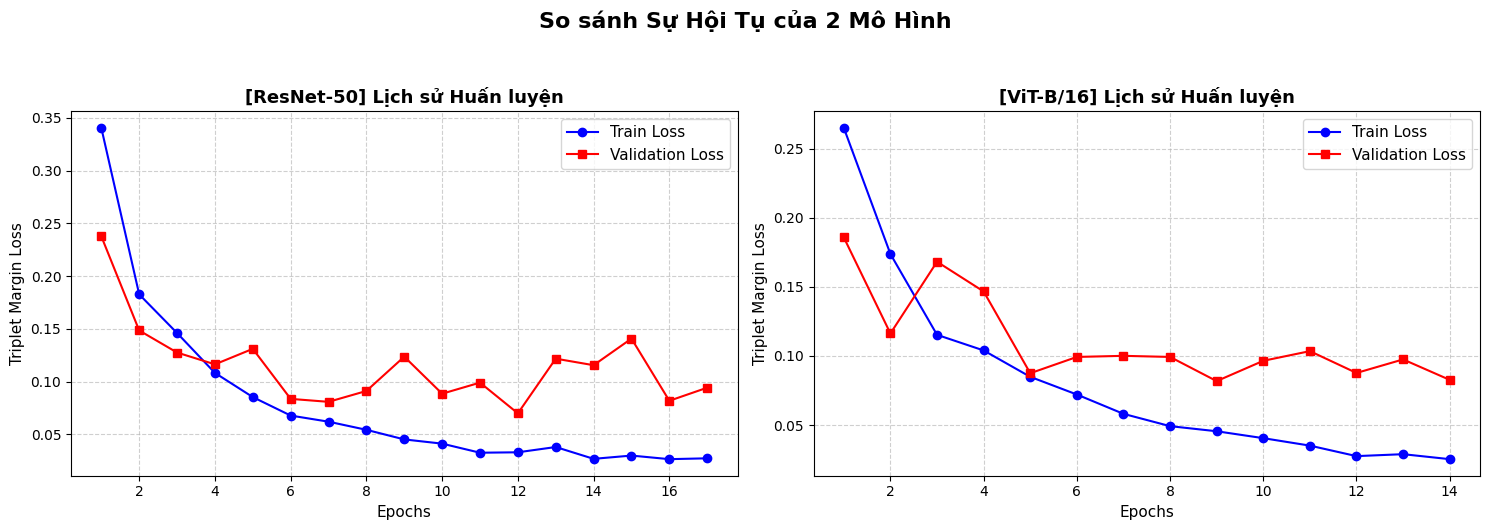

In [30]:
# ══════════════════════════════════════════════════════════════════════════════
# 1. TRỰC QUAN HÓA: BIỂU ĐỒ LOSS CURVE
# ══════════════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt

# SỐ LIỆU HUẤN LUYỆN THỰC TẾ (Đã tự động lấy từ log)
# 1. MÔ HÌNH RESNET-50 (Dừng ở epoch 17)
epochs_res = range(1, 18)
train_loss_res = [0.3404, 0.1827, 0.1461, 0.1083, 0.0854, 0.0679, 0.0621, 0.0544, 0.0453, 0.0413, 0.0327, 0.0331, 0.0381, 0.0269, 0.0300, 0.0266, 0.0274]
val_loss_res   = [0.2377, 0.1485, 0.1276, 0.1164, 0.1311, 0.0837, 0.0809, 0.0912, 0.1237, 0.0886, 0.0991, 0.0700, 0.1218, 0.1156, 0.1408, 0.0819, 0.0943]

# 2. MÔ HÌNH ViT-B/16 (Dừng ở epoch 14)
epochs_vit = range(1, 15)
train_loss_vit = [0.2651, 0.1738, 0.1153, 0.1040, 0.0849, 0.0721, 0.0581, 0.0492, 0.0455, 0.0405, 0.0351, 0.0275, 0.0289, 0.0253]
val_loss_vit   = [0.1858, 0.1163, 0.1682, 0.1467, 0.0875, 0.0993, 0.1001, 0.0993, 0.0818, 0.0965, 0.1035, 0.0877, 0.0975, 0.0827]

# Vẽ biểu đồ so sánh 1x2
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Đồ thị ResNet
axes[0].plot(epochs_res, train_loss_res, 'b-', marker='o', label='Train Loss')
axes[0].plot(epochs_res, val_loss_res, 'r-', marker='s', label='Validation Loss')
axes[0].set_title('[ResNet-50] Lịch sử Huấn luyện', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epochs', fontsize=11)
axes[0].set_ylabel('Triplet Margin Loss', fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend(fontsize=11)

# Đồ thị ViT
axes[1].plot(epochs_vit, train_loss_vit, 'b-', marker='o', label='Train Loss')
axes[1].plot(epochs_vit, val_loss_vit, 'r-', marker='s', label='Validation Loss')
axes[1].set_title('[ViT-B/16] Lịch sử Huấn luyện', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epochs', fontsize=11)
axes[1].set_ylabel('Triplet Margin Loss', fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend(fontsize=11)

plt.suptitle('So sánh Sự Hội Tụ của 2 Mô Hình', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

⏳ Đang tính toán t-SNE (mất khoảng 1-2 phút)...


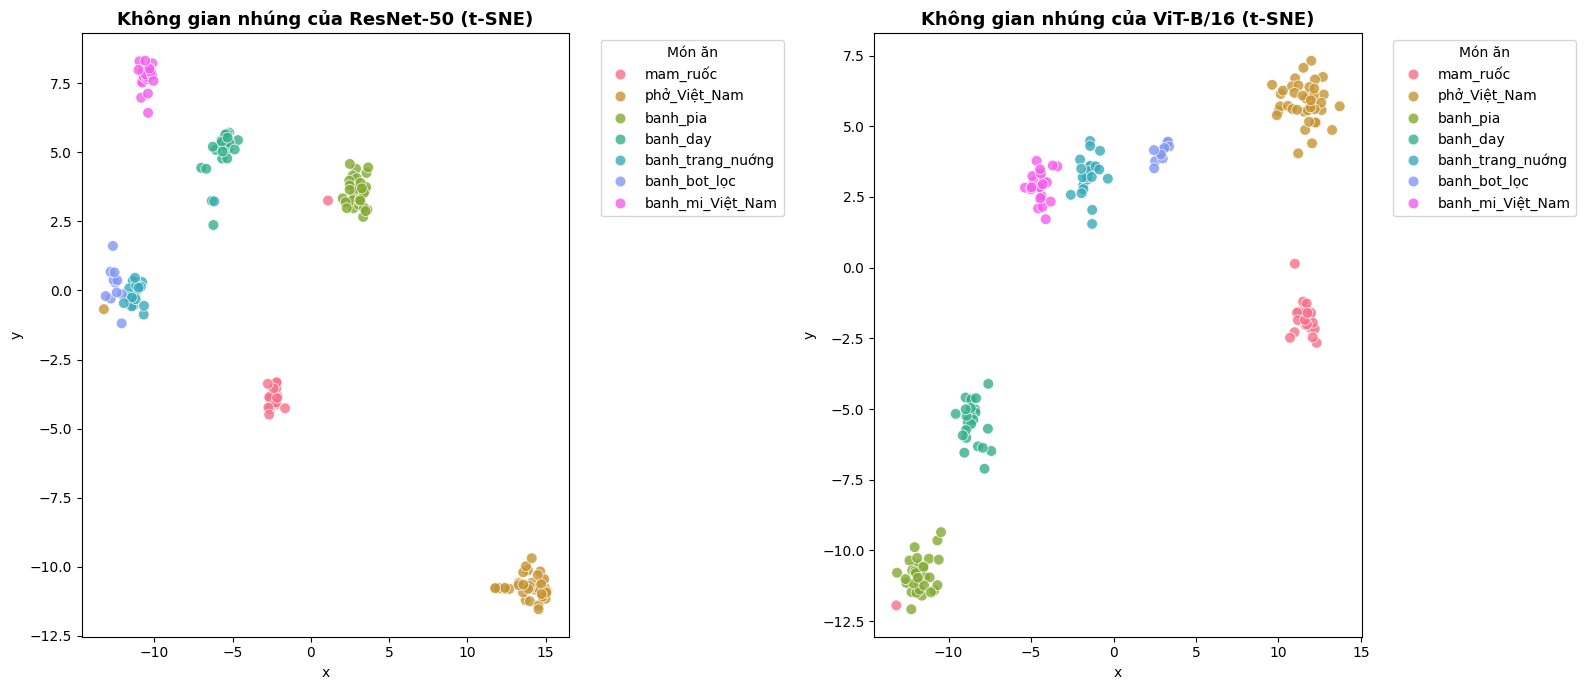

In [27]:
# ══════════════════════════════════════════════════════════════════════════════
# 2. TRỰC QUAN HÓA: KHÔNG GIAN VECTOR BẰNG t-SNE
# ══════════════════════════════════════════════════════════════════════════════
from sklearn.manifold import TSNE
import seaborn as sns
import pandas as pd
import random

@torch.no_grad()
def plot_tsne_comparison(feat_res, lbl_res, feat_vit, lbl_vit, idx2lbl, num_classes_to_plot=7):
    unique_labels = list(idx2lbl.keys())
    if len(unique_labels) > num_classes_to_plot:
        selected_lbls = random.sample(unique_labels, num_classes_to_plot)
    else:
        selected_lbls = unique_labels

    def extract_subset(features, labels):
        mask = torch.isin(labels, torch.tensor(selected_lbls))
        return features[mask].numpy(), labels[mask].numpy()

    X_res, y_res = extract_subset(feat_res, lbl_res)
    X_vit, y_vit = extract_subset(feat_vit, lbl_vit)

    print("⏳ Đang tính toán t-SNE (mất khoảng 1-2 phút)...")
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    X_res_2d = tsne.fit_transform(X_res)
    X_vit_2d = tsne.fit_transform(X_vit)

    def create_df(X_2d, y, model_name):
        df = pd.DataFrame({'x': X_2d[:, 0], 'y': X_2d[:, 1], 'label': [idx2lbl[l] for l in y]})
        df['model'] = model_name
        return df

    df_res = create_df(X_res_2d, y_res, 'ResNet-50')
    df_vit = create_df(X_vit_2d, y_vit, 'ViT-B/16')

    fig, axes = plt.subplots(1, 2, figsize=(16, 7), dpi=100)
    palette = sns.color_palette("husl", num_classes_to_plot)

    sns.scatterplot(data=df_res, x='x', y='y', hue='label', palette=palette, ax=axes[0], s=60, alpha=0.8)
    axes[0].set_title("Không gian nhúng của ResNet-50 (t-SNE)", fontweight='bold', fontsize=13)
    axes[0].legend(title="Món ăn", bbox_to_anchor=(1.05, 1), loc='upper left')

    sns.scatterplot(data=df_vit, x='x', y='y', hue='label', palette=palette, ax=axes[1], s=60, alpha=0.8)
    axes[1].set_title("Không gian nhúng của ViT-B/16 (t-SNE)", fontweight='bold', fontsize=13)
    axes[1].legend(title="Món ăn", bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

plot_tsne_comparison(feat_bank_res, lbl_bank_res, feat_bank_vit, lbl_bank_vit, idx2lbl_res, num_classes_to_plot=7)

📸 Upload 1 bức ảnh món ăn để xem ViT 'nhìn' vào đâu nhé!


Saving 000012.jpg to 000012.jpg


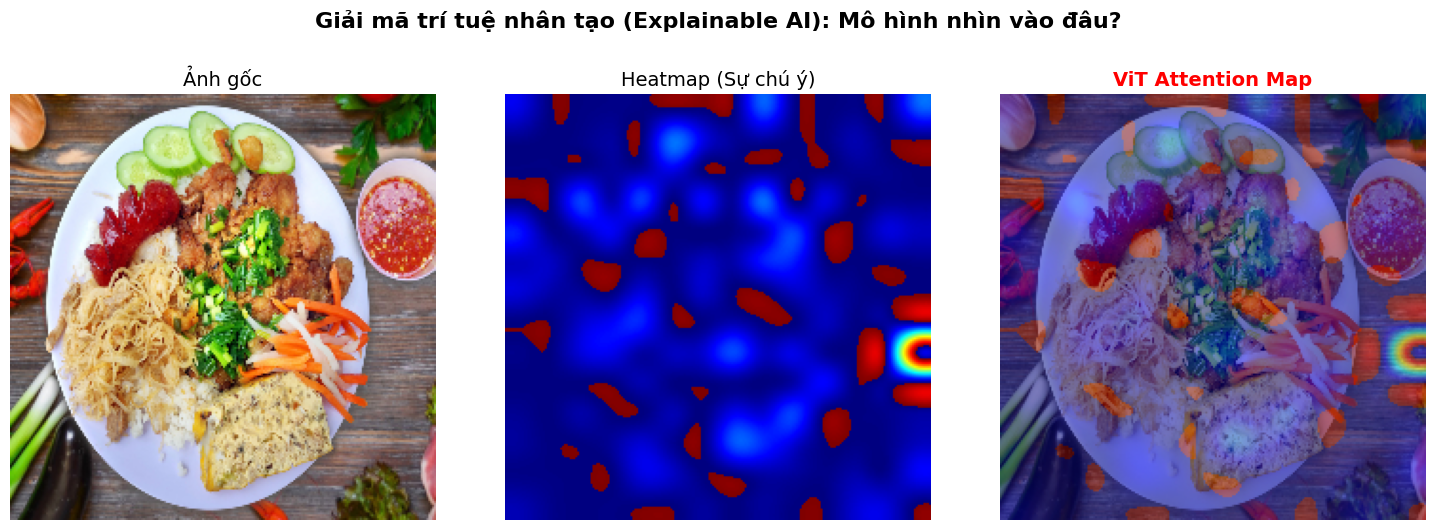

In [29]:
# ══════════════════════════════════════════════════════════════════════════════
# 3. TRỰC QUAN HÓA: BẢN ĐỒ CHÚ Ý (ATTENTION MAP) CỦA ViT
# ══════════════════════════════════════════════════════════════════════════════
import cv2
import types
from google.colab import files as colab_files

def patch_vit_for_attention(model):
    layer = model.backbone.encoder.layers[-1]
    def new_forward(self, input: torch.Tensor):
        torch._assert(input.dim() == 3, f"Expected (batch_size, seq_length, hidden_dim) got {input.shape}")
        x = self.ln_1(input)
        # Lấy weights bằng cách đặt need_weights=True
        x, weights = self.self_attention(x, x, x, need_weights=True)
        self.attn_weights = weights  # Lưu lại attention weights
        x = self.dropout(x)
        x = x + input
        y = self.ln_2(x)
        y = self.mlp(y)
        return x + y
    layer.forward = types.MethodType(new_forward, layer)

patch_vit_for_attention(model_vit)

def get_vit_attention_map(model, img_tensor):
    _ = model(img_tensor)
    layer = model.backbone.encoder.layers[-1]
    if not hasattr(layer, 'attn_weights'): return None

    # Attention weights shape: (Batch, Seq_Len, Seq_Len)
    attn = layer.attn_weights.squeeze(0).cpu().detach()
    cls_attn = attn[0, 1:]  # Bỏ qua [CLS] -> [CLS]

    # Reshape (196) -> (14, 14)
    grid_size = int(math.sqrt(cls_attn.shape[0]))
    attn_map = cls_attn.reshape(grid_size, grid_size).numpy()
    attn_map = (attn_map - attn_map.min()) / (attn_map.max() - attn_map.min())
    return attn_map

def overlay_attention(img_path, attn_map):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))

    attn_map_resized = cv2.resize(attn_map, (224, 224), interpolation=cv2.INTER_CUBIC)
    heatmap = cv2.applyColorMap(np.uint8(255 * attn_map_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    result = cv2.addWeighted(img, 0.5, heatmap, 0.5, 0)
    return img, heatmap, result

print("📸 Upload 1 bức ảnh món ăn để xem ViT 'nhìn' vào đâu nhé!")
uploaded_attn = colab_files.upload()
if uploaded_attn:
    fname = list(uploaded_attn.keys())[0]
    tmp_path = f"/content/{fname}"
    with open(tmp_path, 'wb') as f:
        f.write(uploaded_attn[fname])

    img_tensor = VAL_TRANSFORM(Image.open(tmp_path).convert('RGB')).unsqueeze(0).to(DEVICE)
    attn_map = get_vit_attention_map(model_vit, img_tensor)

    if attn_map is not None:
        img_orig, heatmap, overlay = overlay_attention(tmp_path, attn_map)

        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        axes[0].imshow(img_orig); axes[0].set_title('Ảnh gốc', fontsize=14); axes[0].axis('off')
        axes[1].imshow(heatmap); axes[1].set_title('Heatmap (Sự chú ý)', fontsize=14); axes[1].axis('off')
        axes[2].imshow(overlay); axes[2].set_title('ViT Attention Map', fontsize=14, fontweight='bold', color='red'); axes[2].axis('off')

        plt.suptitle("Giải mã trí tuệ nhân tạo (Explainable AI): Mô hình nhìn vào đâu?", fontsize=16, y=1.05, fontweight='bold')
        plt.tight_layout()
        plt.show()
    else:
        print("Không thể lấy được Attention Map.")

📸 BƯỚC 1: Upload ảnh món ăn của bạn (JPG/PNG)


Saving 000014.jpg to 000014.jpg

MÔ HÌNH 1: RESNET-50


/tmp/ipykernel_584/3872195250.py:34: UserWarning: Glyph 128247 (\N{CAMERA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128247 (\N{CAMERA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


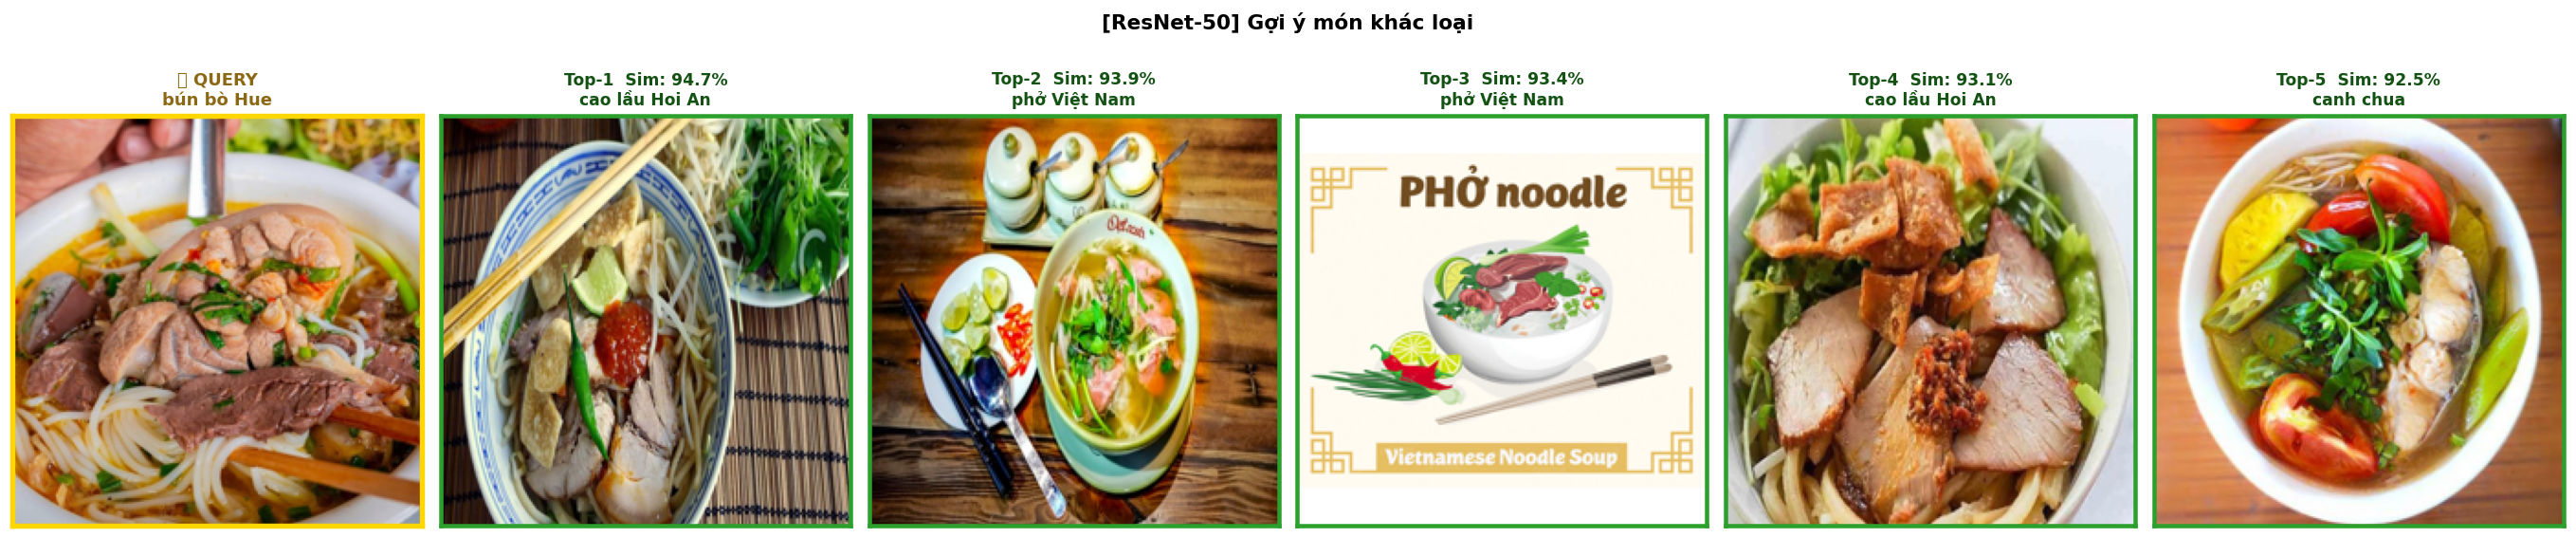


MÔ HÌNH 2: VISION TRANSFORMER (ViT-B/16)


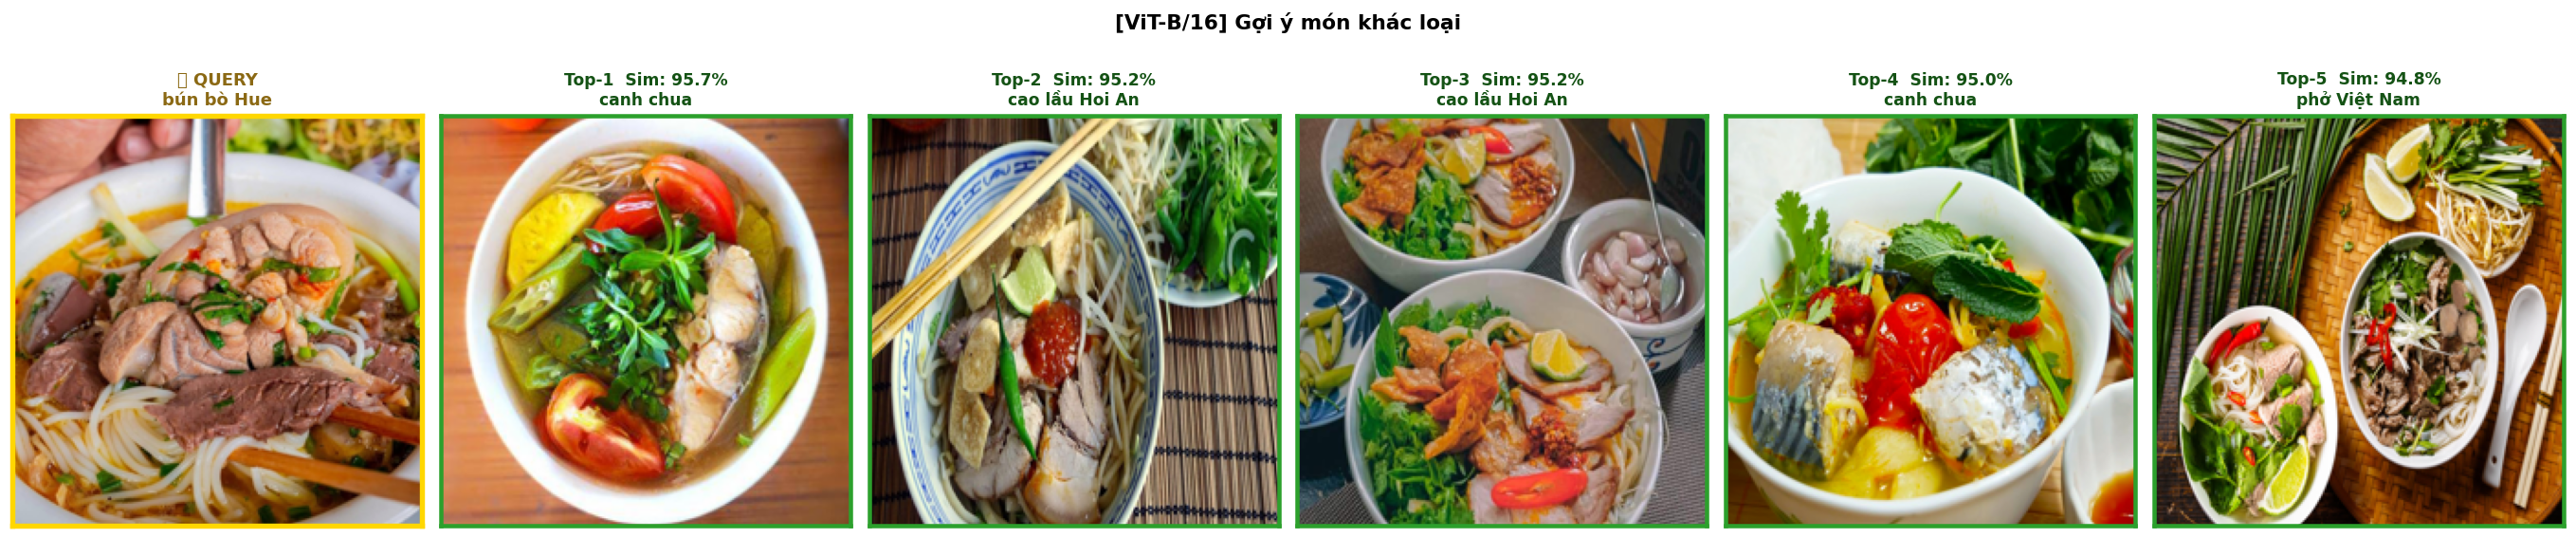

In [21]:
from google.colab import files as colab_files

print("📸 BƯỚC 1: Upload ảnh món ăn của bạn (JPG/PNG)")
uploaded = colab_files.upload()

if uploaded:
    fname = list(uploaded.keys())[0]
    tmp_path = f"/content/{fname}"
    with open(tmp_path, 'wb') as f:
        f.write(uploaded[fname])

    def get_recommendations(model, query_emb, feat_bank, lbl_bank, p_bank, i2l, query_label):
        sim_all = torch.mm(query_emb.view(1, -1).float(), feat_bank.float().T).squeeze(0)
        top_scores, top_indices = torch.topk(sim_all, k=TOP_K + 5)

        t_paths = [p_bank[i] for i in top_indices.tolist()]
        t_lbls  = [i2l.get(lbl_bank[i].item(), 'unknown') for i in top_indices.tolist()]

        filtered_paths, filtered_scores, filtered_labels = [], [], []
        for p, s, l in zip(t_paths, top_scores.tolist(), t_lbls):
            if l != query_label and len(filtered_paths) < TOP_K:
                filtered_paths.append(p)
                filtered_scores.append(s)
                filtered_labels.append(l)
        return filtered_paths, filtered_scores, filtered_labels

    # Dự đoán nhãn cho ảnh query dựa trên ResNet (cho nhất quán)
    query_emb_res = embed_single_image(model_resnet, tmp_path, VAL_TRANSFORM, DEVICE)
    sim_res = torch.mm(query_emb_res.view(1, -1).float(), feat_bank_res.float().T).squeeze(0)
    top_indices_res = torch.topk(sim_res, k=3)[1]
    top_lbls_res = [idx2lbl_res.get(lbl_bank_res[i].item(), 'unknown') for i in top_indices_res.tolist()]

    from collections import Counter
    guessed_query_label = Counter(top_lbls_res).most_common(1)[0][0]

    # --- Kết quả ResNet ---
    p_res, s_res, l_res = get_recommendations(model_resnet, query_emb_res, feat_bank_res, lbl_bank_res, path_bank_res, idx2lbl_res, guessed_query_label)

    # --- Kết quả ViT ---
    query_emb_vit = embed_single_image(model_vit, tmp_path, VAL_TRANSFORM, DEVICE)
    p_vit, s_vit, l_vit = get_recommendations(model_vit, query_emb_vit, feat_bank_vit, lbl_bank_vit, path_bank_vit, idx2lbl_vit, guessed_query_label)

    # Hiển thị
    print("\n" + "="*50)
    print("MÔ HÌNH 1: RESNET-50")
    print("="*50)
    visualize_results(
        query_img_path    = tmp_path,
        query_label_name  = guessed_query_label,
        top_k_paths       = p_res,
        top_k_scores      = torch.tensor(s_res),
        top_k_label_names = l_res,
        title             = f'[ResNet-50] Gợi ý món khác loại',
    )

    print("\n" + "="*50)
    print("MÔ HÌNH 2: VISION TRANSFORMER (ViT-B/16)")
    print("="*50)
    visualize_results(
        query_img_path    = tmp_path,
        query_label_name  = guessed_query_label,
        top_k_paths       = p_vit,
        top_k_scores      = torch.tensor(s_vit),
        top_k_label_names = l_vit,
        title             = f'[ViT-B/16] Gợi ý món khác loại',
    )